In [6]:
selected_backbone = "efficientnet_b0"


In [5]:
# Imports, reproducibility, and dataset statistics

import os
import random
from pathlib import Path
import numpy as np

try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, Subset
    from torchvision import datasets, transforms, models
except ImportError as exc:
    raise ImportError(
        "PyTorch and torchvision are required. Install them in your notebook environment before running this notebook."
    ) from exc

import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report, f1_score

SEED = 42
DATA_DIR = "lavender_dataset_splitted_stress"

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

def compute_dataset_mean_std(data_dir, img_size=224, batch_size=8):
    dataset = datasets.ImageFolder(
        root=data_dir,
        transform=transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ]),
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    mean = torch.zeros(3)
    std = torch.zeros(3)
    total = 0

    for images, _ in loader:
        b = images.size(0)
        images = images.view(b, images.size(1), -1)
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total += b

    mean /= total
    std /= total
    return mean, std, dataset.classes, len(dataset)

if not os.path.isdir(DATA_DIR):
    raise SystemExit(f"Dataset directory not found: {DATA_DIR}")

mean, std, class_names, dataset_size = compute_dataset_mean_std(DATA_DIR, img_size=224)
print(f"Dataset size: {dataset_size}")
print(f"Classes: {class_names}")
print(f"Dataset mean: {mean}")
print(f"Dataset std: {std}")

# ImageNet statistics are used for pretrained transfer learning transforms.
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
print(f"ImageNet normalization: mean={IMAGENET_MEAN}, std={IMAGENET_STD}")


Dataset size: 118
Classes: ['not_stressed', 'stressed']
Dataset mean: tensor([0.2229, 0.2028, 0.1973])
Dataset std: tensor([0.1884, 0.1824, 0.1612])
ImageNet normalization: mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)


In [7]:
# Transfer-learning model, freezing policy, loaders, and train/eval utilities

if "selected_backbone" not in globals():
    selected_backbone = "efficientnet_b0"


def build_model(num_classes, use_imagenet=True):
    weights = models.EfficientNet_B0_Weights.DEFAULT if use_imagenet and hasattr(models, "EfficientNet_B0_Weights") else None
    model = models.efficientnet_b0(weights=weights)
    in_features = model.classifier[-1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes),
    )
    return model


def freeze_backbone(model):
    for p in model.parameters(): # Freeze all parameters by default
        p.requires_grad = False
    
    for p in model.classifier.parameters(): # Always unfreeze the head
        p.requires_grad = True


def unfreeze_last_blocks(model):
    for p in model.features[-1].parameters(): # Unfreeze the last block of the backbone
        p.requires_grad = True
    for p in model.classifier.parameters(): # Ensure the head is also unfrozen
        p.requires_grad = True


def build_stage2_param_groups(model, backbone_lr, head_lr):
    backbone_params = [p for p in model.features[-1].parameters() if p.requires_grad]
    head_params = [p for p in model.classifier.parameters() if p.requires_grad]

    groups = []
    if backbone_params:
        groups.append({"params": backbone_params, "lr": backbone_lr})
    if head_params:
        groups.append({"params": head_params, "lr": head_lr})
    return groups


def get_loaders_kfold(
    data_dir,
    batch_size=16,
    img_size=224,
    n_splits=5,
    seed=42,
    mean=IMAGENET_MEAN, # Use ImageNet stats for pretrained models, or dataset stats for training from scratch
    std=IMAGENET_STD,
):
    train_transform = transforms.Compose([ # Data augmentation for training
        transforms.RandomResizedCrop(img_size, scale=(0.75, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
        transforms.RandomRotation(degrees=20),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
        transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
    ])

    val_transform = transforms.Compose([ 
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    full_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
    labels = full_dataset.targets 
    classes = full_dataset.classes 
    n_samples = len(full_dataset)

    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    splits = list(splitter.split(np.arange(n_samples), labels))

    fold_loaders = []
    for train_idx, val_idx in splits:
        train_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
        val_dataset = datasets.ImageFolder(root=data_dir, transform=val_transform)

        train_subset = Subset(train_dataset, train_idx)
        val_subset = Subset(val_dataset, val_idx)

        train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=False)
        val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

        fold_loaders.append((train_loader, val_loader))

    return fold_loaders, len(classes), classes


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device, return_predictions=False):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            if return_predictions:
                all_labels.extend(labels.cpu().numpy().tolist())
                all_preds.extend(preds.cpu().numpy().tolist())

    avg_loss = running_loss / total
    avg_acc = correct / total

    if return_predictions:
        return avg_loss, avg_acc, all_labels, all_preds
    return avg_loss, avg_acc


def save_checkpoint(path, model, optimizer, fold_idx, epoch, backbone, num_classes, val_loss, val_acc, stage):
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "fold": fold_idx,
            "epoch": epoch,
            "backbone": backbone,
            "num_classes": num_classes,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "stage": stage,
        },
        path,
    )


def plot_loss_curves(train_losses, val_losses, fold_idx):
    plt.figure(figsize=(10, 5))
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, "b-o", label="Train Loss", linewidth=2, markersize=5)
    plt.plot(epochs, val_losses, "r-o", label="Val Loss", linewidth=2, markersize=5)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Fold {fold_idx} - Training/Validation Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()



Fold 1/5 | backbone=efficientnet_b0 | ImageNet=True


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /Users/osama/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 43.6MB/s]


[Stage1][Epoch 1/5] train_loss=0.7100 train_acc=0.4681 | val_loss=0.6625 val_acc=0.5833
[Stage1][Epoch 2/5] train_loss=0.7114 train_acc=0.5319 | val_loss=0.6422 val_acc=0.6250
[Stage1][Epoch 3/5] train_loss=0.6825 train_acc=0.5851 | val_loss=0.6492 val_acc=0.6667
[Stage1][Epoch 4/5] train_loss=0.6102 train_acc=0.7128 | val_loss=0.6569 val_acc=0.5833
[Stage1][Epoch 5/5] train_loss=0.6329 train_acc=0.6596 | val_loss=0.6599 val_acc=0.6250


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:61: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Stage2][Epoch 1/20] train_loss=0.5850 train_acc=0.7340 | val_loss=0.6467 val_acc=0.5000 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 2/20] train_loss=0.5906 train_acc=0.7340 | val_loss=0.6540 val_acc=0.5833 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 3/20] train_loss=0.6042 train_acc=0.7021 | val_loss=0.6450 val_acc=0.5833 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 4/20] train_loss=0.5820 train_acc=0.7021 | val_loss=0.6455 val_acc=0.6250 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 5/20] train_loss=0.5496 train_acc=0.7128 | val_loss=0.6372 val_acc=0.6667 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 6/20] train_loss=0.5451 train_acc=0.7234 | val_loss=0.6421 val_acc=0.6250 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 7/20] train_loss=0.5522 train_acc=0.7660 | val_loss=0.6515 val_acc=0.6250 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 8/20] train_loss=0.5158 train_acc=0.7340 | val_loss=0.6527 val_acc=0.6250 | group0=1.00e-04, group1=1.00e-03
[Stage2]

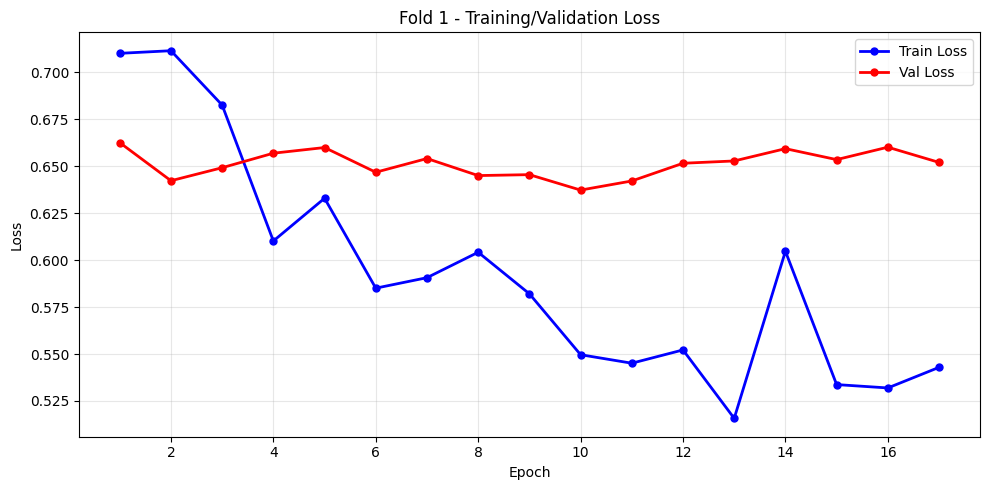

/var/folders/np/b2sgncvd6q71hxrmhl0lk75w0000gn/T/ipykernel_28704/3982512125.py:136: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_ckpt, map_loca

Fold 1 best-checkpoint test_loss=0.6372, test_acc=0.6667, macro_f1=0.6643
Confusion Matrix:
[[9 4]
 [4 7]]
Classification Report:
              precision    recall  f1-score   support

not_stressed     0.6923    0.6923    0.6923        13
    stressed     0.6364    0.6364    0.6364        11

    accuracy                         0.6667        24
   macro avg     0.6643    0.6643    0.6643        24
weighted avg     0.6667    0.6667    0.6667        24


Fold 2/5 | backbone=efficientnet_b0 | ImageNet=True
[Stage1][Epoch 1/5] train_loss=0.7037 train_acc=0.5851 | val_loss=0.7278 val_acc=0.3333
[Stage1][Epoch 2/5] train_loss=0.6950 train_acc=0.5213 | val_loss=0.7313 val_acc=0.4583
[Stage1][Epoch 3/5] train_loss=0.6635 train_acc=0.6277 | val_loss=0.7120 val_acc=0.5417
[Stage1][Epoch 4/5] train_loss=0.6379 train_acc=0.6915 | val_loss=0.7007 val_acc=0.5833
[Stage1][Epoch 5/5] train_loss=0.6088 train_acc=0.7021 | val_loss=0.6956 val_acc=0.6250


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:61: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Stage2][Epoch 1/20] train_loss=0.6195 train_acc=0.6383 | val_loss=0.7095 val_acc=0.5833 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 2/20] train_loss=0.6118 train_acc=0.6915 | val_loss=0.6973 val_acc=0.5833 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 3/20] train_loss=0.6062 train_acc=0.6489 | val_loss=0.7086 val_acc=0.5833 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 4/20] train_loss=0.5889 train_acc=0.6702 | val_loss=0.7087 val_acc=0.6250 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 5/20] train_loss=0.5576 train_acc=0.7234 | val_loss=0.7248 val_acc=0.6250 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 6/20] train_loss=0.5673 train_acc=0.6809 | val_loss=0.7198 val_acc=0.6667 | group0=5.00e-05, group1=5.00e-04
[Stage2][Epoch 7/20] train_loss=0.6281 train_acc=0.6596 | val_loss=0.7062 val_acc=0.6667 | group0=5.00e-05, group1=5.00e-04
Early stopping at epoch 7 (no improvement for 7 epochs)


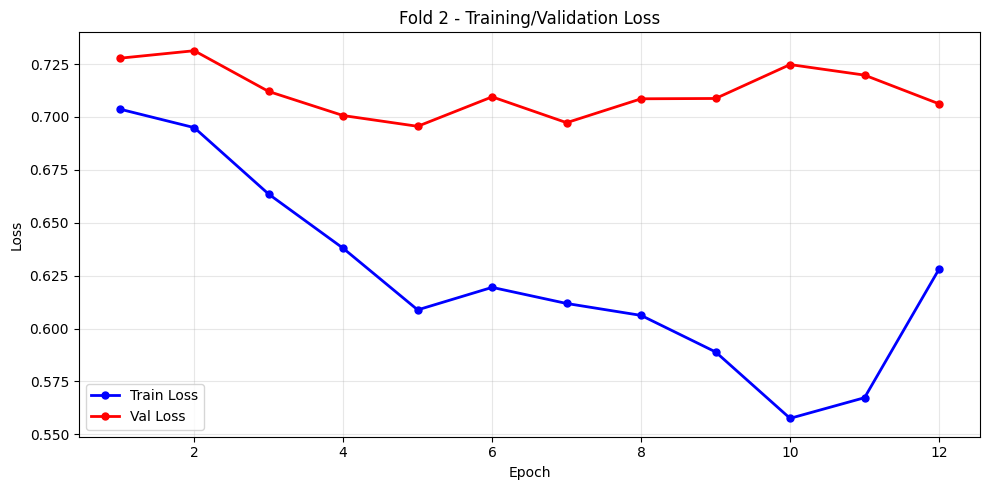

/var/folders/np/b2sgncvd6q71hxrmhl0lk75w0000gn/T/ipykernel_28704/3982512125.py:136: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_ckpt, map_loca

Fold 2 best-checkpoint test_loss=0.6956, test_acc=0.6250, macro_f1=0.5253
Confusion Matrix:
[[13  0]
 [ 9  2]]
Classification Report:
              precision    recall  f1-score   support

not_stressed     0.5909    1.0000    0.7429        13
    stressed     1.0000    0.1818    0.3077        11

    accuracy                         0.6250        24
   macro avg     0.7955    0.5909    0.5253        24
weighted avg     0.7784    0.6250    0.5434        24


Fold 3/5 | backbone=efficientnet_b0 | ImageNet=True
[Stage1][Epoch 1/5] train_loss=0.7324 train_acc=0.5106 | val_loss=0.7475 val_acc=0.4167
[Stage1][Epoch 2/5] train_loss=0.6811 train_acc=0.6170 | val_loss=0.6985 val_acc=0.4583
[Stage1][Epoch 3/5] train_loss=0.6498 train_acc=0.6277 | val_loss=0.6790 val_acc=0.5833
[Stage1][Epoch 4/5] train_loss=0.6488 train_acc=0.6064 | val_loss=0.6723 val_acc=0.5417
[Stage1][Epoch 5/5] train_loss=0.6204 train_acc=0.6702 | val_loss=0.6615 val_acc=0.6250


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:61: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Stage2][Epoch 1/20] train_loss=0.6760 train_acc=0.6170 | val_loss=0.6570 val_acc=0.5833 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 2/20] train_loss=0.6619 train_acc=0.6383 | val_loss=0.6457 val_acc=0.5833 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 3/20] train_loss=0.6338 train_acc=0.5745 | val_loss=0.6286 val_acc=0.5833 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 4/20] train_loss=0.5842 train_acc=0.6809 | val_loss=0.6259 val_acc=0.6667 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 5/20] train_loss=0.6521 train_acc=0.6277 | val_loss=0.6353 val_acc=0.6250 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 6/20] train_loss=0.5870 train_acc=0.6596 | val_loss=0.6387 val_acc=0.6667 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 7/20] train_loss=0.5358 train_acc=0.7553 | val_loss=0.6386 val_acc=0.6667 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 8/20] train_loss=0.5845 train_acc=0.7128 | val_loss=0.6362 val_acc=0.6250 | group0=5.00e-05, group1=5.00e-04
[Stage2]

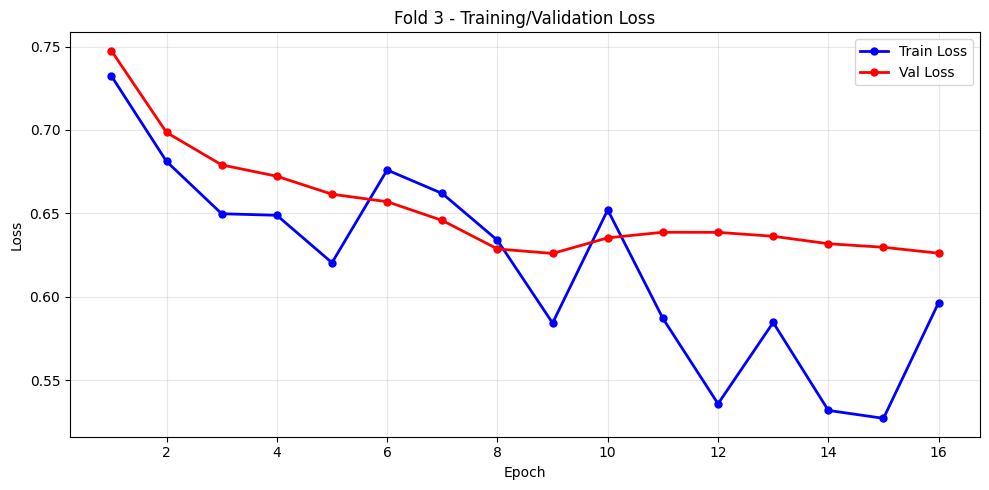

/var/folders/np/b2sgncvd6q71hxrmhl0lk75w0000gn/T/ipykernel_28704/3982512125.py:136: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_ckpt, map_loca

Fold 3 best-checkpoint test_loss=0.6259, test_acc=0.6667, macro_f1=0.6444
Confusion Matrix:
[[11  2]
 [ 6  5]]
Classification Report:
              precision    recall  f1-score   support

not_stressed     0.6471    0.8462    0.7333        13
    stressed     0.7143    0.4545    0.5556        11

    accuracy                         0.6667        24
   macro avg     0.6807    0.6503    0.6444        24
weighted avg     0.6779    0.6667    0.6519        24


Fold 4/5 | backbone=efficientnet_b0 | ImageNet=True
[Stage1][Epoch 1/5] train_loss=0.7173 train_acc=0.5368 | val_loss=0.7256 val_acc=0.4783
[Stage1][Epoch 2/5] train_loss=0.6714 train_acc=0.6105 | val_loss=0.7385 val_acc=0.4783
[Stage1][Epoch 3/5] train_loss=0.6769 train_acc=0.6105 | val_loss=0.7248 val_acc=0.4783
[Stage1][Epoch 4/5] train_loss=0.6395 train_acc=0.6842 | val_loss=0.7254 val_acc=0.3913
[Stage1][Epoch 5/5] train_loss=0.6135 train_acc=0.7263 | val_loss=0.7369 val_acc=0.3913


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:61: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Stage2][Epoch 1/20] train_loss=0.6427 train_acc=0.6421 | val_loss=0.7387 val_acc=0.4348 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 2/20] train_loss=0.6270 train_acc=0.7158 | val_loss=0.7201 val_acc=0.4348 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 3/20] train_loss=0.5826 train_acc=0.7474 | val_loss=0.7182 val_acc=0.6087 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 4/20] train_loss=0.5778 train_acc=0.7158 | val_loss=0.7053 val_acc=0.6522 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 5/20] train_loss=0.5700 train_acc=0.7263 | val_loss=0.7006 val_acc=0.6522 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 6/20] train_loss=0.5616 train_acc=0.7474 | val_loss=0.6819 val_acc=0.6522 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 7/20] train_loss=0.5586 train_acc=0.7368 | val_loss=0.6944 val_acc=0.6522 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 8/20] train_loss=0.5519 train_acc=0.7158 | val_loss=0.6957 val_acc=0.6087 | group0=1.00e-04, group1=1.00e-03
[Stage2]

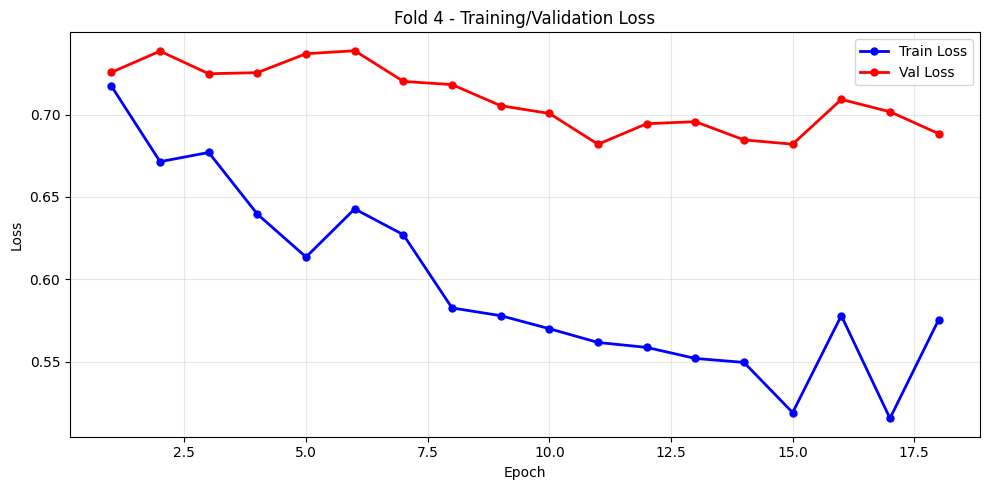

/var/folders/np/b2sgncvd6q71hxrmhl0lk75w0000gn/T/ipykernel_28704/3982512125.py:136: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_ckpt, map_loca

Fold 4 best-checkpoint test_loss=0.6819, test_acc=0.6522, macro_f1=0.6462
Confusion Matrix:
[[9 3]
 [5 6]]
Classification Report:
              precision    recall  f1-score   support

not_stressed     0.6429    0.7500    0.6923        12
    stressed     0.6667    0.5455    0.6000        11

    accuracy                         0.6522        23
   macro avg     0.6548    0.6477    0.6462        23
weighted avg     0.6542    0.6522    0.6482        23


Fold 5/5 | backbone=efficientnet_b0 | ImageNet=True
[Stage1][Epoch 1/5] train_loss=0.7095 train_acc=0.5053 | val_loss=0.7349 val_acc=0.3043
[Stage1][Epoch 2/5] train_loss=0.7294 train_acc=0.4000 | val_loss=0.7281 val_acc=0.3913
[Stage1][Epoch 3/5] train_loss=0.6664 train_acc=0.6105 | val_loss=0.6980 val_acc=0.4783
[Stage1][Epoch 4/5] train_loss=0.6770 train_acc=0.5789 | val_loss=0.6856 val_acc=0.5217
[Stage1][Epoch 5/5] train_loss=0.6434 train_acc=0.6316 | val_loss=0.6660 val_acc=0.6087


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:61: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Stage2][Epoch 1/20] train_loss=0.6599 train_acc=0.6000 | val_loss=0.6824 val_acc=0.6522 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 2/20] train_loss=0.6301 train_acc=0.6632 | val_loss=0.6727 val_acc=0.6522 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 3/20] train_loss=0.6226 train_acc=0.6211 | val_loss=0.6611 val_acc=0.7391 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 4/20] train_loss=0.6280 train_acc=0.6526 | val_loss=0.6514 val_acc=0.7391 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 5/20] train_loss=0.6328 train_acc=0.6316 | val_loss=0.6362 val_acc=0.7391 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 6/20] train_loss=0.6129 train_acc=0.6526 | val_loss=0.6271 val_acc=0.7391 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 7/20] train_loss=0.6203 train_acc=0.6632 | val_loss=0.6097 val_acc=0.7826 | group0=1.00e-04, group1=1.00e-03
[Stage2][Epoch 8/20] train_loss=0.5972 train_acc=0.6526 | val_loss=0.5944 val_acc=0.7826 | group0=1.00e-04, group1=1.00e-03
[Stage2]

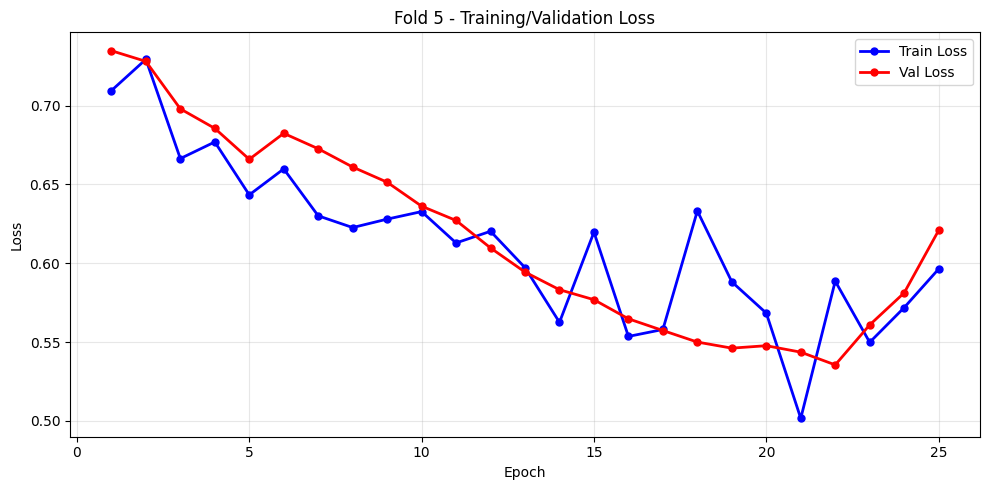

/var/folders/np/b2sgncvd6q71hxrmhl0lk75w0000gn/T/ipykernel_28704/3982512125.py:136: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(best_ckpt, map_loca

Fold 5 best-checkpoint test_loss=0.5355, test_acc=0.7391, macro_f1=0.7262
Confusion Matrix:
[[11  1]
 [ 5  6]]
Classification Report:
              precision    recall  f1-score   support

not_stressed     0.6875    0.9167    0.7857        12
    stressed     0.8571    0.5455    0.6667        11

    accuracy                         0.7391        23
   macro avg     0.7723    0.7311    0.7262        23
weighted avg     0.7686    0.7391    0.7288        23


Cross-Validation Summary
Fold 1: acc=0.6667, macro_f1=0.6643
Fold 2: acc=0.6250, macro_f1=0.5253
Fold 3: acc=0.6667, macro_f1=0.6444
Fold 4: acc=0.6522, macro_f1=0.6462
Fold 5: acc=0.7391, macro_f1=0.7262
Mean acc   : 0.6699 ± 0.0378
Mean macroF1: 0.6413 ± 0.0652


In [9]:
# Main training and testing loop (freeze then fine-tune)

import argparse


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--data-dir", type=str, default=DATA_DIR)
    parser.add_argument("--backbone", type=str, default=selected_backbone, choices=["resnet18", "efficientnet_b0", "convnext_tiny"])
    parser.add_argument("--img-size", type=int, default=224)
    parser.add_argument("--batch-size", type=int, default=16)
    parser.add_argument("--n-splits", type=int, default=5)

    parser.add_argument("--stage1-epochs", type=int, default=5)
    parser.add_argument("--stage2-epochs", type=int, default=20)

    parser.add_argument("--head-lr", type=float, default=1e-3)
    parser.add_argument("--backbone-lr", type=float, default=1e-4)
    parser.add_argument("--weight-decay", type=float, default=1e-4)
    parser.add_argument("--early-stop-patience", type=int, default=7, help="Stop Stage 2 if val_loss does not improve for N epochs")

    parser.add_argument("--save-path", type=str, default="./models_weights_tl")
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    parser.add_argument("--no-imagenet", action="store_true", help="Disable ImageNet pretrained initialization")
    args = parser.parse_args([])

    if not os.path.isdir(args.data_dir):
        raise SystemExit(f"Dataset directory not found: {args.data_dir}")


    use_imagenet = not args.no_imagenet
    device = torch.device(args.device)

    fold_loaders, num_classes, classes = get_loaders_kfold(
        data_dir=args.data_dir,
        batch_size=args.batch_size,
        img_size=args.img_size,
        n_splits=args.n_splits,
        seed=SEED,
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD,
    )

    criterion = nn.CrossEntropyLoss()
    fold_results = []

    for fold_idx, (train_loader, val_loader) in enumerate(fold_loaders, start=1):
        print("\n" + "=" * 72)
        print(f"Fold {fold_idx}/{args.n_splits} | backbone={args.backbone} | ImageNet={use_imagenet}")
        print("=" * 72)

        model = build_model( num_classes=num_classes, use_imagenet=use_imagenet).to(device)

        train_losses, val_losses = [], []
        best_val_loss = float("inf")
        best_ckpt = f"{args.save_path}_{args.backbone}_fold{fold_idx}.pth"

        # Stage 1: train head only (backbone frozen)
        freeze_backbone(model)
        optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=args.head_lr, weight_decay=args.weight_decay)

        for epoch in range(1, args.stage1_epochs + 1):
            train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc = evaluate(model, val_loader, criterion, device)

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            print(
                f"[Stage1][Epoch {epoch}/{args.stage1_epochs}] "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
            )

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                save_checkpoint(
                    path=best_ckpt,
                    model=model,
                    optimizer=optimizer,
                    fold_idx=fold_idx,
                    epoch=epoch,
                    backbone=args.backbone,
                    num_classes=num_classes,
                    val_loss=val_loss,
                    val_acc=val_acc,
                    stage="head-only",
                )

        # Stage 2: unfreeze last block(s) + head
        unfreeze_last_blocks(model)
        stage2_groups = build_stage2_param_groups(model, args.backbone_lr, args.head_lr)
        optimizer = optim.Adam(stage2_groups, weight_decay=args.weight_decay)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5, verbose=True)

        es_counter = 0
        for epoch in range(1, args.stage2_epochs + 1):
            train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
            val_loss, val_acc = evaluate(model, val_loader, criterion, device)
            scheduler.step(val_loss)

            train_losses.append(train_loss)
            val_losses.append(val_loss)

            lr_info = ", ".join([f"group{i}={pg['lr']:.2e}" for i, pg in enumerate(optimizer.param_groups)])
            print(
                f"[Stage2][Epoch {epoch}/{args.stage2_epochs}] "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | {lr_info}"
            )

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                es_counter = 0
                save_checkpoint(
                    path=best_ckpt,
                    model=model,
                    optimizer=optimizer,
                    fold_idx=fold_idx,
                    epoch=args.stage1_epochs + epoch,
                    backbone=args.backbone,
                    num_classes=num_classes,
                    val_loss=val_loss,
                    val_acc=val_acc,
                    stage="fine-tune",
                )
            else:
                es_counter += 1
                if es_counter >= args.early_stop_patience:
                    print(f"Early stopping at epoch {epoch} (no improvement for {args.early_stop_patience} epochs)")
                    break

        plot_loss_curves(train_losses, val_losses, fold_idx)

        # Testing on fold validation set using best checkpoint
        checkpoint = torch.load(best_ckpt, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])

        test_loss, test_acc, y_true, y_pred = evaluate(
            model, val_loader, criterion, device, return_predictions=True
        )
        macro_f1 = f1_score(y_true, y_pred, average="macro")

        print(f"Fold {fold_idx} best-checkpoint test_loss={test_loss:.4f}, test_acc={test_acc:.4f}, macro_f1={macro_f1:.4f}")
        print("Confusion Matrix:")
        print(confusion_matrix(y_true, y_pred))
        print("Classification Report:")
        print(classification_report(y_true, y_pred, target_names=classes, digits=4))

        fold_results.append({"fold": fold_idx, "acc": test_acc, "macro_f1": macro_f1})

    # Aggregate summary
    accs = [r["acc"] for r in fold_results]
    f1s = [r["macro_f1"] for r in fold_results]

    print("\n" + "=" * 72)
    print("Cross-Validation Summary")
    print("=" * 72)
    for r in fold_results:
        print(f"Fold {r['fold']}: acc={r['acc']:.4f}, macro_f1={r['macro_f1']:.4f}")
    print(f"Mean acc   : {np.mean(accs):.4f} ± {np.std(accs):.4f}")
    print(f"Mean macroF1: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")
    print("=" * 72)


main()
